# Hate Speech Detection using RNN, LSTM, and Word2Vec Embeddings
### 6CS012 Final Portfolio Project 2026 — Part III: Language Task
---

## 0. Install Required Libraries

In [1]:
!pip install nltk wordcloud gensim contractions gradio -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 57.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 8.5 MB/s eta 0:00:00


## 1. Import Libraries

In [2]:
# Core
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

# NLP
import nltk
import contractions
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud
from collections import Counter

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Keras / TensorFlow
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

# Gensim Word2Vec
import gensim.downloader as api

# NLTK Downloads
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

print("All libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


All libraries imported successfully!
TensorFlow version: 2.20.0


---
## 4.5.1 Text Preprocessing, Tokenization, and Sequence Padding

### Step 1: Load Dataset

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Load dataset
df = pd.read_csv('/content/drive/MyDrive/6CS012 - Artificial Intelligence and Machine Learning./Portfolio 2/Hate Speech Detection Dataset/hatevsoffensive_language.csv')

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Dataset Shape: (24783, 2)

First 5 rows:


,label,text
0,neither,!!! RT @mayasolovely: As a woman you shouldn't...
1,offensive language,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,offensive language,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,offensive language,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,offensive language,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...


In [5]:
# Inspect columns
print("Columns:", df.columns.tolist())
print("\nData Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())

Columns: ['label', 'text']

Data Types:
label    object
text     object
dtype: object

Missing Values:
label    0
text     0
dtype: int64


Class Distribution:
label
1    19190
2     4163
0     1430
Name: count, dtype: int64


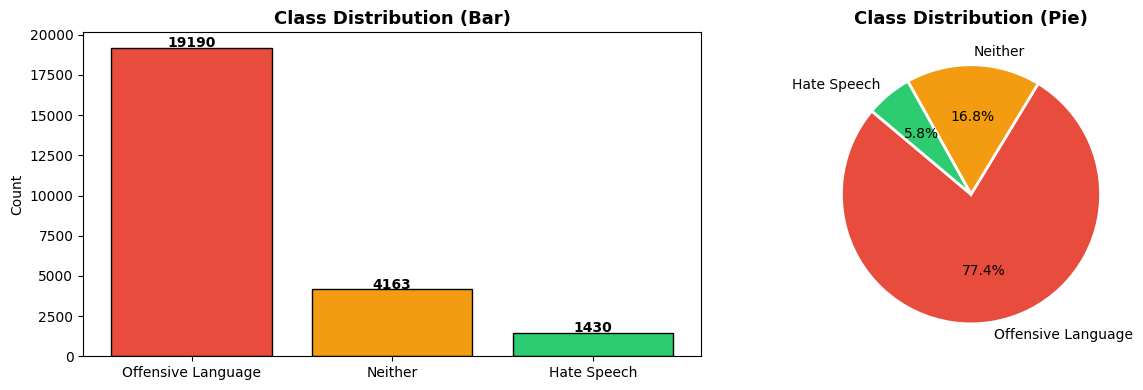

In [6]:
TEXT_COL  = 'text'
LABEL_COL = 'label'
# Labels: 0 = hate speech, 1 = offensive language, 2 = neither

df = df[[TEXT_COL, LABEL_COL]].dropna()
df.columns = ['text', 'label']

# Map string labels to integers based on the comment:
# 'hate speec' -> 0
# 'offensive language' -> 1
# 'neither' -> 2
label_mapping_str_to_int = {
    'hate speec': 0,
    'offensive language': 1,
    'neither': 2
}
df['label'] = df['label'].map(label_mapping_str_to_int)

print("Class Distribution:")
print(df['label'].value_counts())

# Map numerical labels to readable names for plotting
label_map = {0: 'Hate Speech', 1: 'Offensive Language', 2: 'Neither'}
df['label_name'] = df['label'].map(label_map)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
counts = df['label_name'].value_counts()
colors = ['#E74C3C', '#F39C12', '#2ECC71']

axes[0].bar(counts.index, counts.values, color=colors, edgecolor='black')
axes[0].set_title('Class Distribution (Bar)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=colors, startangle=140, wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Class Distribution (Pie)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### Step 2: Text Cleaning

In [7]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    """Full preprocessing pipeline for a single text string."""
    if not isinstance(text, str):
        return ""

    # 1. Lowercase
    text = text.lower()

    # 2. Expand contractions (e.g., don't -> do not)
    text = contractions.fix(text)

    # 3. Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)

    # 4. Remove mentions (@user) and hashtags (#tag)
    text = re.sub(r'@\w+|#\w+', '', text)

    # 5. Remove numbers
    text = re.sub(r'\d+', '', text)

    # 6. Remove special characters and punctuation (keep only letters and spaces)
    text = re.sub(r'[^a-z\s]', '', text)

    # 7. Tokenize
    tokens = text.split()

    # 8. Remove stopwords & lemmatize
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words and len(w) > 2]

    return ' '.join(tokens)

# Apply cleaning
print("Cleaning text data...")
df['clean_text'] = df['text'].apply(clean_text)

# Drop rows where cleaning produced empty strings
df = df[df['clean_text'].str.strip() != ''].reset_index(drop=True)

print(f"Dataset size after cleaning: {len(df)} rows")
print("\nSample - Before vs After Cleaning:")
for i in range(3):
    print(f"\n[{i+1}] ORIGINAL: {df['text'].iloc[i][:120]}")
    print(f"    CLEANED : {df['clean_text'].iloc[i][:120]}")

Cleaning text data...
Dataset size after cleaning: 24761 rows

Sample - Before vs After Cleaning:

[1] ORIGINAL: !!! RT @mayasolovely: As a woman you shouldn't complain about cleaning up your house. &amp; as a man you should always t
    CLEANED : woman complain cleaning house amp man always take trash

[2] ORIGINAL: !!!!! RT @mleew17: boy dats cold...tyga dwn bad for cuffin dat hoe in the 1st place!!
    CLEANED : boy dat coldtyga dwn bad cuffin dat hoe place

[3] ORIGINAL: !!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby4life: You ever fuck a bitch and she start to cry? You be confused as shit
    CLEANED : dawg ever fuck bitch start cry confused shit


### Step 3: Visualize Cleaned Data

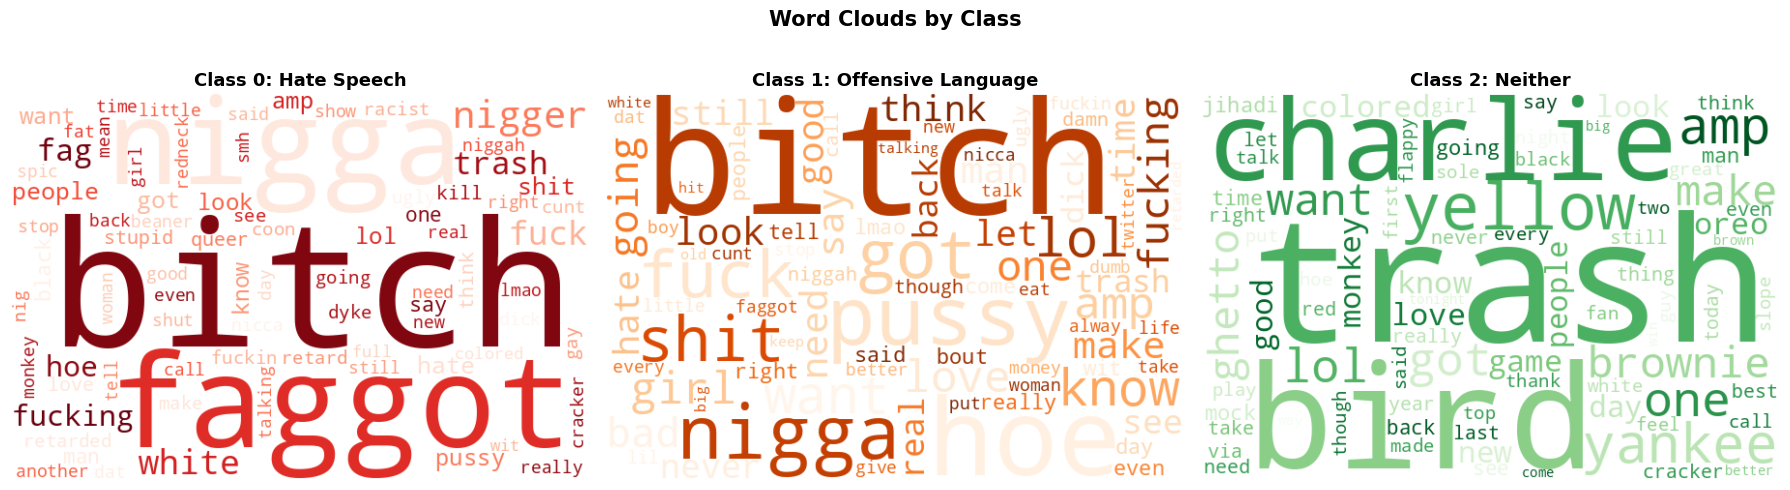

In [8]:
# ── Word Clouds per Class ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
class_colors = {0: 'Reds', 1: 'Oranges', 2: 'Greens'}
class_titles = {0: 'Hate Speech', 1: 'Offensive Language', 2: 'Neither'}

for cls in [0, 1, 2]:
    subset_text = ' '.join(df[df['label'] == cls]['clean_text'].tolist())
    wc = WordCloud(
        width=600, height=400,
        background_color='white',
        colormap=class_colors[cls],
        max_words=80,
        collocations=False
    ).generate(subset_text)
    axes[cls].imshow(wc, interpolation='bilinear')
    axes[cls].axis('off')
    axes[cls].set_title(f'Class {cls}: {class_titles[cls]}', fontsize=13, fontweight='bold')

plt.suptitle('Word Clouds by Class', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()

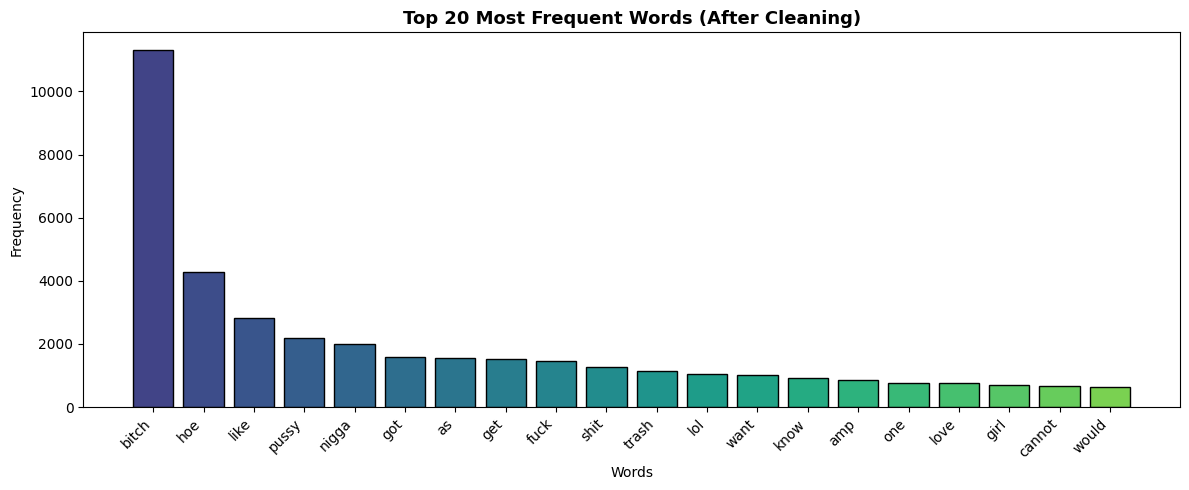

In [9]:
# ── Top 20 Most Frequent Words (overall) ──
all_words = ' '.join(df['clean_text'].tolist()).split()
word_freq = Counter(all_words)
top_20 = word_freq.most_common(20)

words, freqs = zip(*top_20)
plt.figure(figsize=(12, 5))
bars = plt.bar(words, freqs, color=plt.cm.viridis(np.linspace(0.2, 0.8, 20)), edgecolor='black')
plt.title('Top 20 Most Frequent Words (After Cleaning)', fontsize=13, fontweight='bold')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('top_words.png', dpi=150, bbox_inches='tight')
plt.show()

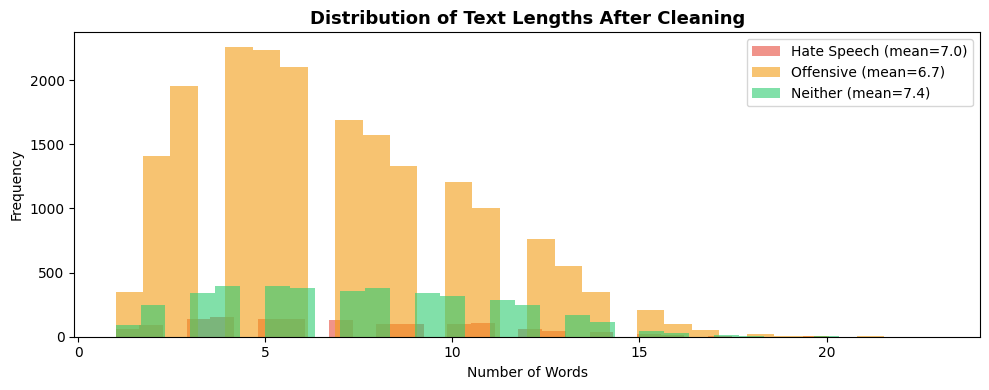


Text Length Stats:
count    24761.000000
mean         6.846694
std          3.522350
min          1.000000
25%          4.000000
50%          6.000000
75%          9.000000
max         23.000000
Name: text_length, dtype: float64


In [10]:
# ── Text Length Distribution ──
df['text_length'] = df['clean_text'].apply(lambda x: len(x.split()))

plt.figure(figsize=(10, 4))
for cls, color, name in zip([0,1,2], ['#E74C3C','#F39C12','#2ECC71'],
                             ['Hate Speech','Offensive','Neither']):
    subset = df[df['label'] == cls]['text_length']
    plt.hist(subset, bins=30, alpha=0.6, color=color, label=f'{name} (mean={subset.mean():.1f})')

plt.title('Distribution of Text Lengths After Cleaning', fontsize=13, fontweight='bold')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.savefig('text_length_dist.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nText Length Stats:")
print(df['text_length'].describe())

### Step 4: Tokenization and Padding

In [11]:
# ── Train/Test Split (80/20) ──
X = df['clean_text'].values
y = df['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples : {len(X_train)}")
print(f"Testing  samples : {len(X_test)}")
print(f"Class distribution in train: {dict(zip(*np.unique(y_train, return_counts=True)))}")

Training samples : 19808
Testing  samples : 4953
Class distribution in train: {np.int64(0): np.int64(1140), np.int64(1): np.int64(15344), np.int64(2): np.int64(3324)}


In [12]:
# ── Keras Tokenizer ──
VOCAB_SIZE = 10000  # top 10,000 words
OOV_TOKEN  = '<OOV>'

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOKEN)
tokenizer.fit_on_texts(X_train)   # fit ONLY on training data

train_sequences = tokenizer.texts_to_sequences(X_train)
test_sequences  = tokenizer.texts_to_sequences(X_test)

print(f"Vocabulary size (unique words): {len(tokenizer.word_index)}")
print(f"Sample sequence (first train): {train_sequences[0][:10]}")

Vocabulary size (unique words): 15728
Sample sequence (first train): [195, 23, 74, 5]


In [13]:
# ── Percentile-based Padding ──
seq_lengths = [len(s) for s in train_sequences]
MAX_LEN = int(np.percentile(seq_lengths, 95))   # 95th percentile
print(f"95th percentile sequence length → MAX_LEN = {MAX_LEN}")

X_train_pad = pad_sequences(train_sequences, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(test_sequences,  maxlen=MAX_LEN, padding='post', truncating='post')

# One-hot encode labels (3 classes)
NUM_CLASSES = 3
y_train_cat = to_categorical(y_train, num_classes=NUM_CLASSES)
y_test_cat  = to_categorical(y_test,  num_classes=NUM_CLASSES)

print(f"X_train_pad shape: {X_train_pad.shape}")
print(f"X_test_pad  shape: {X_test_pad.shape}")
print(f"y_train_cat shape: {y_train_cat.shape}")

95th percentile sequence length → MAX_LEN = 13
X_train_pad shape: (19808, 13)
X_test_pad  shape: (4953, 13)
y_train_cat shape: (19808, 3)


---
## 4.5.2 Model Building and Training

In [14]:
# ── Shared Hyperparameters ──
EMBED_DIM  = 64
BATCH_SIZE = 64
EPOCHS     = 20

callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)
]

histories = {}   # store training histories
models    = {}   # store trained models

### Model 1: Simple RNN with Trainable Embedding

In [15]:
tf.keras.backend.clear_session()

rnn_model = Sequential(name='Simple_RNN', layers=[
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM, input_length=MAX_LEN, name='embedding'),
    SimpleRNN(64, return_sequences=False, name='simple_rnn'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(NUM_CLASSES, activation='softmax', name='output')
])

rnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

rnn_model.summary()

Model: "Simple_RNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [16]:
print("Training Model 1: Simple RNN...")
history_rnn = rnn_model.fit(
    X_train_pad, y_train_cat,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1
)

histories['Simple RNN'] = history_rnn
models['Simple RNN']    = rnn_model
print("Model 1 training complete!")

Training Model 1: Simple RNN...
Epoch 1/20
279/279 ━━━━━━━━━━━━━━━━━━━━ 13s 31ms/step - accuracy: 0.8326 - loss: 0.4797 - val_accuracy: 0.8733 - val_loss: 0.3543 - learning_rate: 0.0010
Epoch 2/20
279/279 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9143 - loss: 0.2600 - val_accuracy: 0.8814 - val_loss: 0.3447 - learning_rate: 0.0010
Epoch 3/20
279/279 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9445 - loss: 0.1727 - val_accuracy: 0.8743 - val_loss: 0.3804 - learning_rate: 0.0010
Epoch 4/20
270/279 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9660 - loss: 0.1105
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
279/279 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9628 - loss: 0.1155 - val_accuracy: 0.8582 - val_loss: 0.4875 - learning_rate: 0.0010
Epoch 5/20
279/279 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9781 - loss: 0.0679 - val_accuracy: 0.8556 - val_loss: 0.5618 - learning_rate: 5.0000e-04
Epoch 5: early stopping
Restoring model weights fro

### Model 2: LSTM with Trainable Embedding

In [17]:
tf.keras.backend.clear_session()

lstm_model = Sequential(name='LSTM_Trainable', layers=[
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM, input_length=MAX_LEN, name='embedding'),
    LSTM(64, return_sequences=False, name='lstm'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(NUM_CLASSES, activation='softmax', name='output')
])

lstm_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

lstm_model.summary()

Model: "LSTM_Trainable"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [18]:
print("Training Model 2: LSTM with Trainable Embedding...")
history_lstm = lstm_model.fit(
    X_train_pad, y_train_cat,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1
)

histories['LSTM'] = history_lstm
models['LSTM']    = lstm_model
print("Model 2 training complete!")

Training Model 2: LSTM with Trainable Embedding...
Epoch 1/20
279/279 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.8375 - loss: 0.4769 - val_accuracy: 0.8804 - val_loss: 0.3427 - learning_rate: 0.0010
Epoch 2/20
279/279 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9072 - loss: 0.2915 - val_accuracy: 0.8753 - val_loss: 0.3434 - learning_rate: 0.0010
Epoch 3/20
279/279 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9285 - loss: 0.2166 - val_accuracy: 0.8758 - val_loss: 0.3398 - learning_rate: 0.0010
Epoch 4/20
279/279 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9443 - loss: 0.1643 - val_accuracy: 0.8829 - val_loss: 0.3813 - learning_rate: 0.0010
Epoch 5/20
278/279 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9575 - loss: 0.1261
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
279/279 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9566 - loss: 0.1274 - val_accuracy: 0.8571 - val_loss: 0.4656 - learning_rate: 0.0010
Epoch 6/20
279/279 ━━━━━━━━━━━━━━━━━

### Model 3: LSTM with Pretrained Word2Vec Embeddings

In [19]:
# ── Load pretrained Word2Vec (Google News, 300-dim) ──
print("Loading pretrained Word2Vec embeddings (word2vec-google-news-300)...")
print("This may take 2-5 minutes on first download...")

w2v_model = api.load('word2vec-google-news-300')
W2V_DIM   = 300
print(f"Word2Vec loaded! Vocabulary size: {len(w2v_model.key_to_index):,}")

Loading pretrained Word2Vec embeddings (word2vec-google-news-300)...
This may take 2-5 minutes on first download...
[==================================================] 100.0% 1662.8/1662.8MB downloaded
Word2Vec loaded! Vocabulary size: 3,000,000


In [20]:
# ── Build Embedding Matrix from Word2Vec ──
word_index = tokenizer.word_index
embedding_matrix = np.zeros((VOCAB_SIZE, W2V_DIM))
matched = 0

for word, idx in word_index.items():
    if idx < VOCAB_SIZE:
        if word in w2v_model.key_to_index:
            embedding_matrix[idx] = w2v_model[word]
            matched += 1

coverage = matched / min(VOCAB_SIZE, len(word_index)) * 100
print(f"Words matched in Word2Vec: {matched}/{min(VOCAB_SIZE, len(word_index))} ({coverage:.1f}% coverage)")
print(f"Embedding matrix shape: {embedding_matrix.shape}")

Words matched in Word2Vec: 7967/10000 (79.7% coverage)
Embedding matrix shape: (10000, 300)


In [21]:
tf.keras.backend.clear_session()

lstm_w2v_model = Sequential(name='LSTM_Word2Vec', layers=[
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=W2V_DIM,
        weights=[embedding_matrix],
        input_length=MAX_LEN,
        trainable=False,          # freeze pretrained weights
        name='w2v_embedding'
    ),
    LSTM(64, return_sequences=False, name='lstm'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(NUM_CLASSES, activation='softmax', name='output')
])

lstm_w2v_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

lstm_w2v_model.summary()

Model: "LSTM_Word2Vec"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ w2v_embedding (Embedding)       │ ?                      │     3,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,000,000 (11.44 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 3,000,000 (11.44 MB)

In [22]:
print("Training Model 3: LSTM with Word2Vec Embeddings...")
history_w2v = lstm_w2v_model.fit(
    X_train_pad, y_train_cat,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1
)

histories['LSTM + Word2Vec'] = history_w2v
models['LSTM + Word2Vec']    = lstm_w2v_model
print("Model 3 training complete!")

Training Model 3: LSTM with Word2Vec Embeddings...
Epoch 1/20
279/279 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.8511 - loss: 0.4357 - val_accuracy: 0.8713 - val_loss: 0.3395 - learning_rate: 0.0010
Epoch 2/20
279/279 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.8826 - loss: 0.3237 - val_accuracy: 0.8763 - val_loss: 0.3310 - learning_rate: 0.0010
Epoch 3/20
279/279 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.8908 - loss: 0.2989 - val_accuracy: 0.8799 - val_loss: 0.3258 - learning_rate: 0.0010
Epoch 4/20
279/279 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.8978 - loss: 0.2847 - val_accuracy: 0.8814 - val_loss: 0.3136 - learning_rate: 0.0010
Epoch 5/20
279/279 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9008 - loss: 0.2700 - val_accuracy: 0.8839 - val_loss: 0.3155 - learning_rate: 0.0010
Epoch 6/20
279/279 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9042 - loss: 0.2604
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
279/279 ━━━━━━━━━━━━━

---
## 4.5.3 Model Training and Evaluation

### Training vs Validation Curves (per Model)

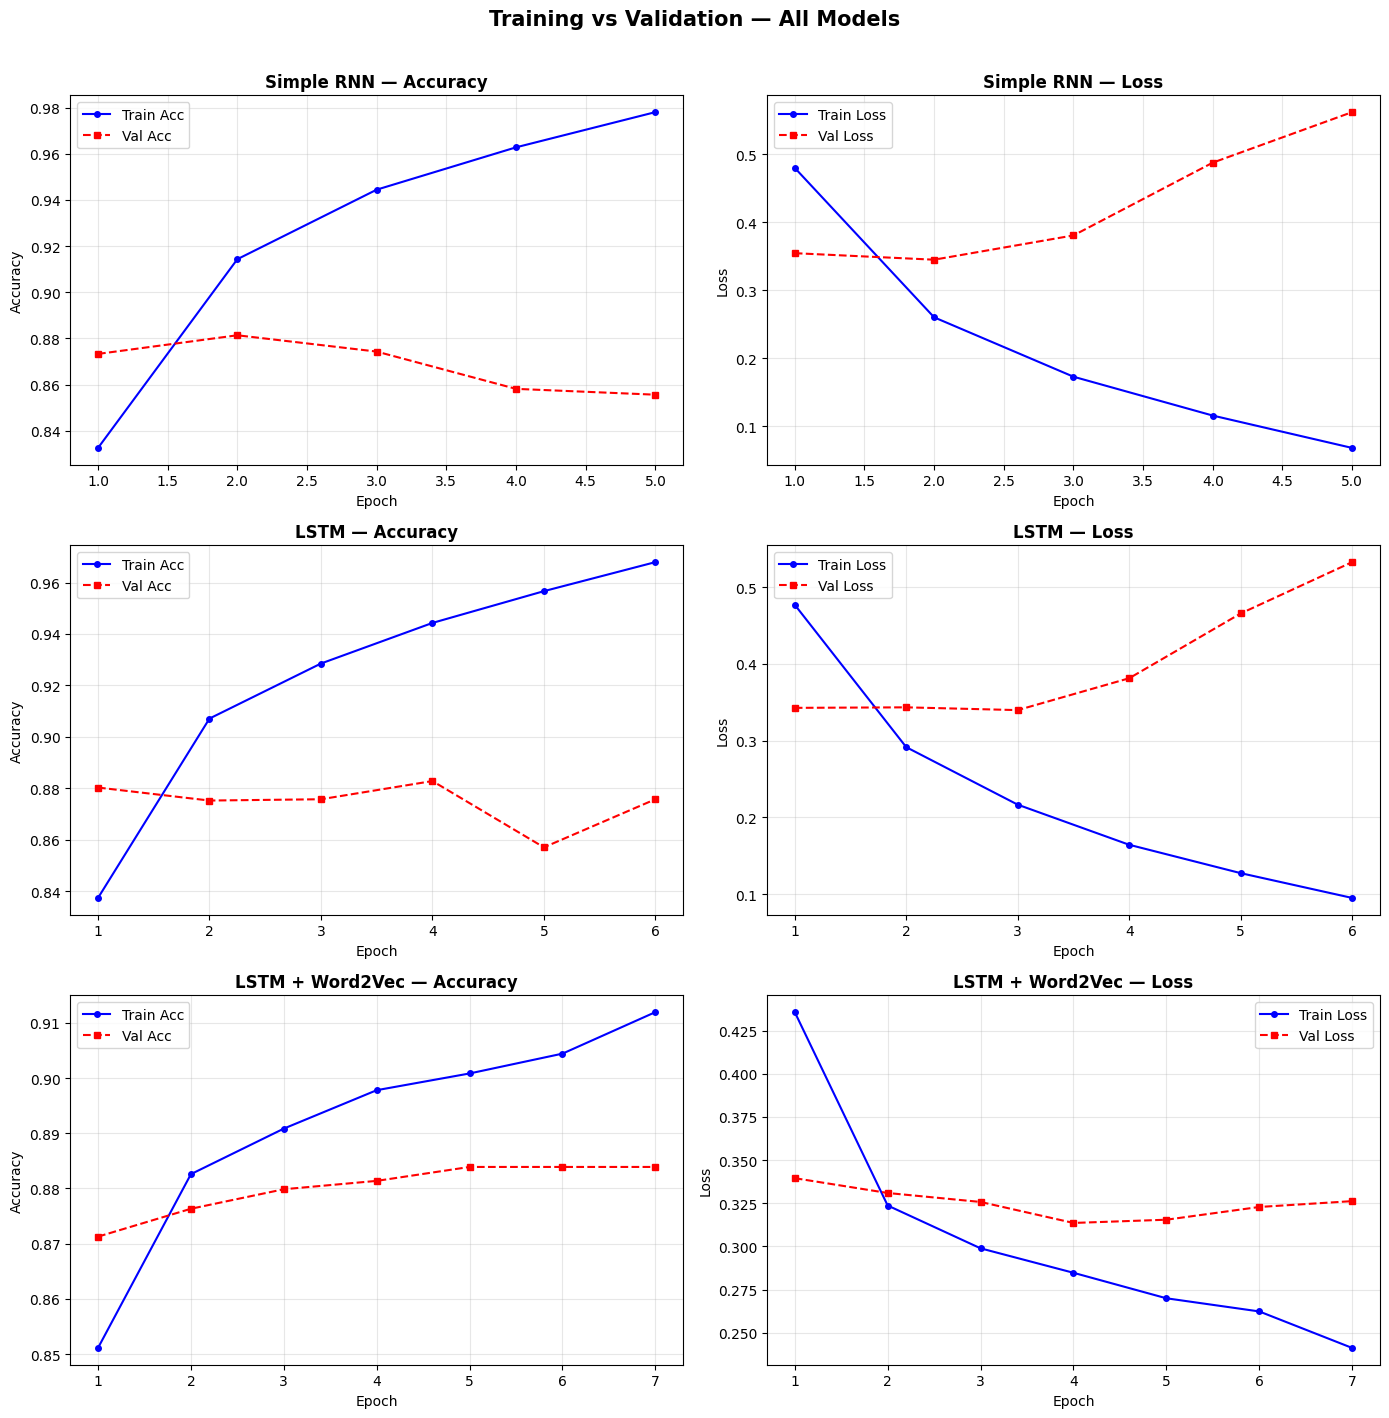

In [23]:
def plot_history(history, model_name, ax_acc, ax_loss):
    """Plot accuracy and loss curves for a single model."""
    acc     = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss     = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(1, len(acc)+1)

    ax_acc.plot(epochs_range, acc,     'b-o', markersize=4, label='Train Acc')
    ax_acc.plot(epochs_range, val_acc, 'r--s', markersize=4, label='Val Acc')
    ax_acc.set_title(f'{model_name} — Accuracy', fontweight='bold')
    ax_acc.set_xlabel('Epoch'); ax_acc.set_ylabel('Accuracy')
    ax_acc.legend(); ax_acc.grid(alpha=0.3)

    ax_loss.plot(epochs_range, loss,     'b-o', markersize=4, label='Train Loss')
    ax_loss.plot(epochs_range, val_loss, 'r--s', markersize=4, label='Val Loss')
    ax_loss.set_title(f'{model_name} — Loss', fontweight='bold')
    ax_loss.set_xlabel('Epoch'); ax_loss.set_ylabel('Loss')
    ax_loss.legend(); ax_loss.grid(alpha=0.3)

fig, axes = plt.subplots(3, 2, figsize=(14, 14))
model_names = ['Simple RNN', 'LSTM', 'LSTM + Word2Vec']

for i, name in enumerate(model_names):
    plot_history(histories[name], name, axes[i][0], axes[i][1])

plt.suptitle('Training vs Validation — All Models', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

### Compare All Models

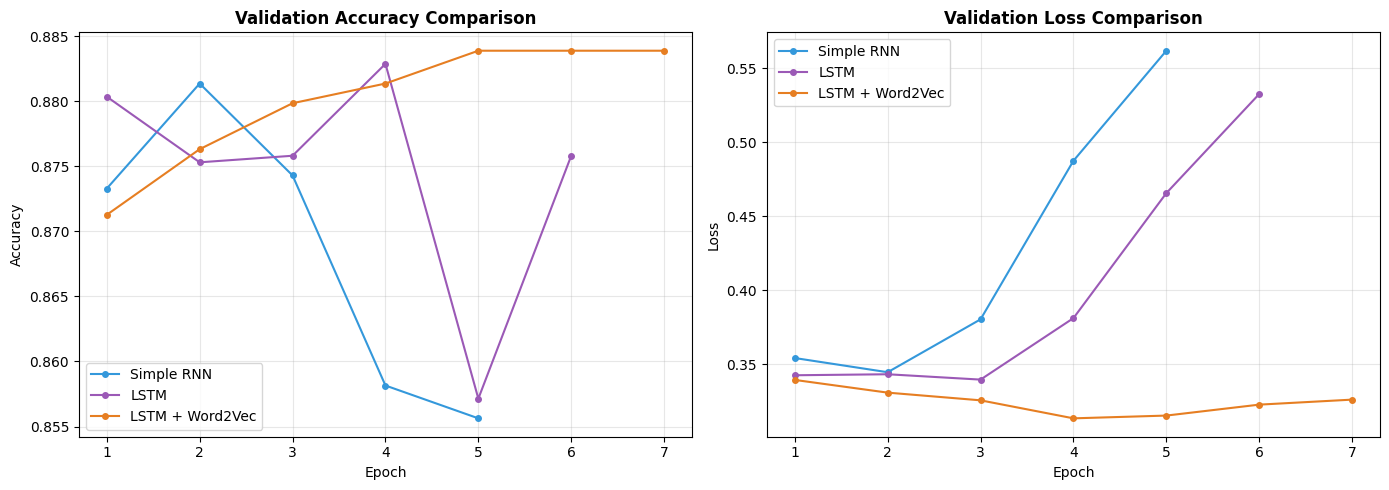

In [24]:
# ── Best Validation Accuracy Comparison ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors_m = ['#3498DB', '#9B59B6', '#E67E22']

for i, (name, hist) in enumerate(histories.items()):
    acc_vals  = hist.history['val_accuracy']
    loss_vals = hist.history['val_loss']
    axes[0].plot(range(1, len(acc_vals)+1),  acc_vals,  color=colors_m[i], marker='o', markersize=4, label=name)
    axes[1].plot(range(1, len(loss_vals)+1), loss_vals, color=colors_m[i], marker='o', markersize=4, label=name)

axes[0].set_title('Validation Accuracy Comparison', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].set_title('Validation Loss Comparison', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### Evaluation: Accuracy, Confusion Matrix, Classification Report

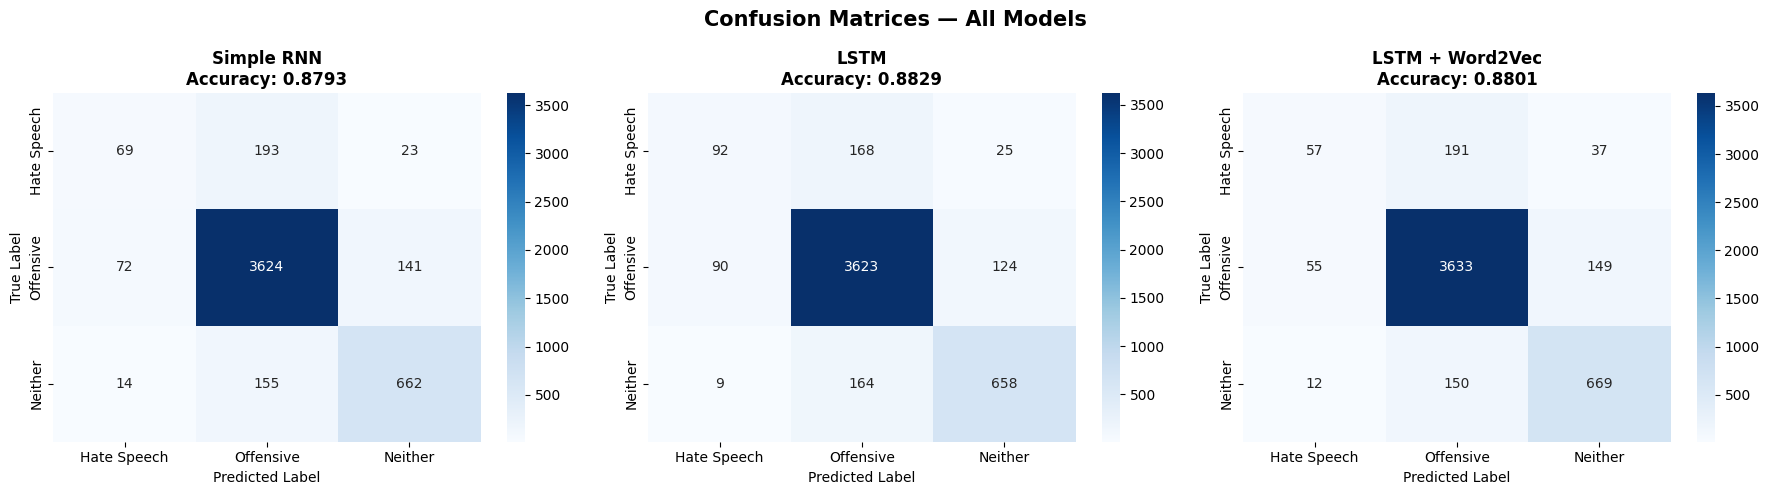

In [25]:
CLASS_NAMES = ['Hate Speech', 'Offensive', 'Neither']

results = {}
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, model) in enumerate(models.items()):
    y_pred_prob = model.predict(X_test_pad, verbose=0)
    y_pred      = np.argmax(y_pred_prob, axis=1)
    acc         = accuracy_score(y_test, y_pred)
    cm          = confusion_matrix(y_test, y_pred)
    report      = classification_report(y_test, y_pred, target_names=CLASS_NAMES, output_dict=True)

    results[name] = {'accuracy': acc, 'cm': cm, 'report': report, 'y_pred': y_pred}

    # Plot confusion matrix
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[i])
    axes[i].set_title(f'{name}\nAccuracy: {acc:.4f}', fontweight='bold')
    axes[i].set_ylabel('True Label')
    axes[i].set_xlabel('Predicted Label')

plt.suptitle('Confusion Matrices — All Models', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

In [26]:
# ── Classification Reports ──
for name, res in results.items():
    print(f"{'='*55}")
    print(f"  MODEL: {name}")
    print(f"  Test Accuracy: {res['accuracy']:.4f}")
    print(f"{'='*55}")
    print(classification_report(y_test, res['y_pred'], target_names=CLASS_NAMES))
    print()

  MODEL: Simple RNN
  Test Accuracy: 0.8793
              precision    recall  f1-score   support

 Hate Speech       0.45      0.24      0.31       285
   Offensive       0.91      0.94      0.93      3837
     Neither       0.80      0.80      0.80       831

    accuracy                           0.88      4953
   macro avg       0.72      0.66      0.68      4953
weighted avg       0.87      0.88      0.87      4953


  MODEL: LSTM
  Test Accuracy: 0.8829
              precision    recall  f1-score   support

 Hate Speech       0.48      0.32      0.39       285
   Offensive       0.92      0.94      0.93      3837
     Neither       0.82      0.79      0.80       831

    accuracy                           0.88      4953
   macro avg       0.74      0.69      0.71      4953
weighted avg       0.87      0.88      0.88      4953


  MODEL: LSTM + Word2Vec
  Test Accuracy: 0.8801
              precision    recall  f1-score   support

 Hate Speech       0.46      0.20      0.28       


Summary Table:
                 Accuracy  Macro F1  Macro Prec  Macro Rec
Simple RNN         0.8793    0.6803      0.7197     0.6611
LSTM               0.8829    0.7066      0.7377     0.6863
LSTM + Word2Vec    0.8801    0.6675      0.7188     0.6506


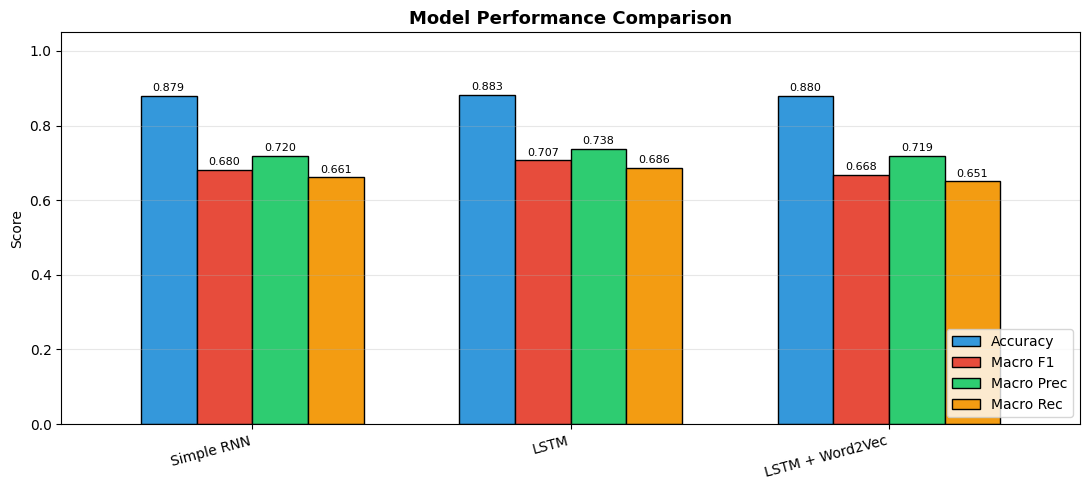

In [27]:
# ── Summary Bar Chart ──
metrics_data = {
    name: {
        'Accuracy':  res['accuracy'],
        'Macro F1':  res['report']['macro avg']['f1-score'],
        'Macro Prec': res['report']['macro avg']['precision'],
        'Macro Rec': res['report']['macro avg']['recall'],
    } for name, res in results.items()
}

metrics_df = pd.DataFrame(metrics_data).T
print("\nSummary Table:")
print(metrics_df.round(4).to_string())

ax = metrics_df.plot(kind='bar', figsize=(11, 5), color=['#3498DB','#E74C3C','#2ECC71','#F39C12'],
                     edgecolor='black', width=0.7)
ax.set_title('Model Performance Comparison', fontsize=13, fontweight='bold')
ax.set_ylabel('Score')
ax.set_xticklabels(metrics_df.index, rotation=15, ha='right')
ax.set_ylim(0, 1.05)
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=8, padding=2)

plt.tight_layout()
plt.savefig('performance_summary.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4.5.4 Error Analysis

In [28]:
# ── Misclassified Examples for each model ──
for name, res in results.items():
    print(f"\n{'='*60}")
    print(f"Error Analysis — {name}")
    print(f"{'='*60}")

    y_pred = res['y_pred']
    wrong_idx = np.where(y_pred != y_test)[0]
    total_wrong = len(wrong_idx)
    print(f"Total misclassified: {total_wrong}/{len(y_test)} ({total_wrong/len(y_test)*100:.1f}%)")

    print(f"\n--- 3 Sample Misclassifications ---")
    for j, idx in enumerate(wrong_idx[:3]):
        true_label = label_map[y_test[idx]]
        pred_label = label_map[y_pred[idx]]
        original   = X_test[idx]
        print(f"\n  Example {j+1}:")
        print(f"    Text (clean) : {original[:120]}")
        print(f"    True Label   : {true_label}")
        print(f"    Predicted    : {pred_label}")


Error Analysis — Simple RNN
Total misclassified: 598/4953 (12.1%)

--- 3 Sample Misclassifications ---

  Example 1:
    Text (clean) : fucking hate coon ahh uncle
    True Label   : Hate Speech
    Predicted    : Offensive Language

  Example 2:
    Text (clean) : love dez right trash right weeden others open
    True Label   : Offensive Language
    Predicted    : Neither

  Example 3:
    Text (clean) : mcrib bun contain chemical azodicarbonamide also used make yoga mat amp sol shoe
    True Label   : Neither
    Predicted    : Offensive Language

Error Analysis — LSTM
Total misclassified: 580/4953 (11.7%)

--- 3 Sample Misclassifications ---

  Example 1:
    Text (clean) : stephan smith saying jay cutler mvp candidate straight retarded
    True Label   : Neither
    Predicted    : Offensive Language

  Example 2:
    Text (clean) : coon watching love hip hop
    True Label   : Offensive Language
    Predicted    : Hate Speech

  Example 3:
    Text (clean) : love dez right trash 

In [29]:
# ── Model Complexity vs Performance Table ──
complexity = {
    'Simple RNN':      rnn_model.count_params(),
    'LSTM':            lstm_model.count_params(),
    'LSTM + Word2Vec': lstm_w2v_model.count_params()
}

comp_df = pd.DataFrame({
    'Total Params':  complexity,
    'Test Accuracy': {n: r['accuracy'] for n, r in results.items()},
    'Macro F1':      {n: r['report']['macro avg']['f1-score'] for n, r in results.items()}
})
print("\nModel Complexity vs Performance:")
print(comp_df.round(4).to_string())


Model Complexity vs Performance:
                 Total Params  Test Accuracy  Macro F1
Simple RNN             650435         0.8793    0.6803
LSTM                   675203         0.8829    0.7066
LSTM + Word2Vec       3095619         0.8801    0.6675


### Discussion: Possible Reasons for Errors

**Key error sources:**

1. **Class Imbalance** — Hate speech is the rarest class; models may struggle to learn its patterns and default to the majority class (offensive language).

2. **Boundary Ambiguity** — Tweets with offensive-but-not-hateful language, sarcasm, or slang straddling class 0 and 1 confuse all models. Humans themselves often disagree on these.

3. **Short/Empty Sequences** — After aggressive cleaning some tweets become too short (1–2 tokens), removing all discriminative signal.

4. **Simple RNN Vanishing Gradients** — For longer sequences, Simple RNN loses context from early tokens; LSTM mitigates this.

5. **Domain Mismatch in Word2Vec** — Word2Vec is trained on Google News (formal), while tweets are informal/noisy. Unknown slang maps to `<OOV>`, reducing its advantage.

**Suggested Improvements:**
- Apply class weighting or SMOTE to address imbalance.
- Use Twitter-specific embeddings (e.g., GloVe Twitter 200d).
- Add a Bidirectional LSTM to capture both directions of context.
- Fine-tune a pretrained BERT or RoBERTa model for state-of-the-art performance.
- Increase training data with augmentation (back-translation, synonym replacement).

---
## 4.5.5 GUI for Real-Time Prediction (Gradio)

In [30]:
import gradio as gr

# Use best model (change 'LSTM + Word2Vec' to whichever performed best)
BEST_MODEL_NAME = 'LSTM + Word2Vec'
best_model = models[BEST_MODEL_NAME]

def predict_tweet(tweet_text):
    """Clean, tokenize, pad, and predict class of input tweet."""
    if not tweet_text.strip():
        return "Please enter some text."

    # Preprocess
    cleaned = clean_text(tweet_text)
    if not cleaned.strip():
        return "Text is empty after cleaning. Try a different input."

    # Tokenize & Pad
    seq     = tokenizer.texts_to_sequences([cleaned])
    padded  = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')

    # Predict
    probs   = best_model.predict(padded, verbose=0)[0]
    pred_class = int(np.argmax(probs))
    confidence = float(probs[pred_class]) * 100

    class_labels = ['🔴 Hate Speech', '🟠 Offensive Language', '🟢 Neither (Neutral)']
    result = f"**Prediction:** {class_labels[pred_class]}\n\n"
    result += f"**Confidence:** {confidence:.1f}%\n\n"
    result += f"**Cleaned Input:** {cleaned}\n\n"
    result += f"**Class Probabilities:**\n"
    for i, (label, prob) in enumerate(zip(['Hate Speech', 'Offensive', 'Neither'], probs)):
        bar = '█' * int(prob * 20)
        result += f"  {label}: {prob*100:.1f}% {bar}\n"

    return result

# Launch Gradio interface
demo = gr.Interface(
    fn=predict_tweet,
    inputs=gr.Textbox(
        lines=3,
        placeholder="Enter a tweet or comment here...",
        label="Input Text"
    ),
    outputs=gr.Markdown(label="Prediction Result"),
    title="🛡️ Hate Speech Detector",
    description=(
        f"Classifies text into: **Hate Speech (0)**, **Offensive Language (1)**, or **Neither (2)**\n"
        f"Model: {BEST_MODEL_NAME}"
    ),
    examples=[
        ["I love everyone, have a great day!"],
        ["You are an idiot and should be ashamed."],
        ["All those people should be eliminated from our country."]
    ],
    theme=gr.themes.Soft()
)

demo.launch(share=True)   # share=True creates a public link in Colab

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://c2522bcf331eb1d3fb.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


---
## Save Models (Optional)

In [31]:
# Save all three models
rnn_model.save('model1_simple_rnn.h5')
lstm_model.save('model2_lstm.h5')
lstm_w2v_model.save('model3_lstm_w2v.h5')

# Save tokenizer
import pickle
with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

print("All models and tokenizer saved successfully!")

All models and tokenizer saved successfully!
